# RUL-Vorhersage von Lithium-Ionen-Batterien

Ziel dieses Notebooks ist die Vorhersage der Remaining Useful Life (RUL) in Equivalent Full Cycles (EFC).

Verwendet werden die regular_alt_batteries ohne Referenzzyklen. Die Validierung erfolgt batteriegetrennt und nach Lebensdauergruppen balanciert, damit keine Zyklen derselben Batterie gleichzeitig im Training und Test vorkommen.

Im Fokus steht der Vergleich zwischen einem bisherigen Basismodell und einem verbesserten Feature-Set mit Degradationsmerkmalen. Besonders relevant ist das Feature `delta_SOH(-120EFC)`, das die SOH-Veränderung über die vergangenen 120 EFC beschreibt und damit die aktuelle Alterungsgeschwindigkeit der Batterie abbildet.

# Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Daten laden

In [29]:
df = pd.read_csv("data_complete.csv")

print(df.shape)
df.head()

(7955, 61)


,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cycle_avg,...,SOH,SOH(-30EFC),SOH(-60EFC),SOH(-90EFC),SOH(-120EFC),delta_SOH(-30EFC),delta_SOH(-60EFC),delta_SOH(-90EFC),delta_SOH(-120EFC),RUL_EFC
0,battery00,True,7424.475,1.001191,17.149865,0.035325,0.189894,0.278888,0.400940,26.569209,...,100.000000,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,0.000000,150.411108
1,battery00,False,12219.679,1.995107,32.833935,0.038305,0.190357,0.282313,0.403624,41.332868,...,99.788050,100.0,100.0,100.0,100.0,0.211950,0.211950,0.211950,0.211950,149.417193
2,battery00,False,17025.679,2.992049,48.630552,0.041295,0.190822,0.285749,0.406316,42.564516,...,99.575454,100.0,100.0,100.0,100.0,0.424546,0.424546,0.424546,0.424546,148.420251
3,battery00,False,21836.339,3.987183,64.388980,0.044280,0.191287,0.289179,0.409004,42.606710,...,99.363243,100.0,100.0,100.0,100.0,0.636757,0.636757,0.636757,0.636757,147.425116
4,battery00,False,29014.698,4.976644,79.798714,0.047247,0.191748,0.292589,0.411676,28.744107,...,99.152243,100.0,100.0,100.0,100.0,0.847757,0.847757,0.847757,0.847757,146.435656


In [30]:
df.columns.tolist()

['batt_label',
 'isRefCycle',
 'time_sec',
 'EFC',
 'E_cum_Wh',
 'Q_norm_at_3.9_V',
 'Q_norm_at_3.8_V',
 'Q_norm_at_3.7_V',
 'Q_norm_at_3.6_V',
 'T_cycle_avg',
 'T_cycle_max',
 'T_cycle_min',
 'T_cum_avg',
 'T_cum_max',
 'T_cum_min',
 'sec_T_over_30',
 'sec_T_over_40',
 'sec_T_over_45',
 'sec_T_over_50',
 'sec_T_over_60',
 'sec_T_st_-20',
 'sec_T_-20_0',
 'sec_T_0_15',
 'sec_T_15_30',
 'sec_T_30_45',
 'sec_T_45_60',
 'sec_T_60_80',
 'sec_T_gt_80',
 'C_rate_cycle_avg',
 'C_rate_cycle_max',
 'C_rate_cum_avg',
 'C_rate_cum_max',
 'sec_C_rate_0_0.5',
 'sec_C_rate_0.5_1',
 'sec_C_rate_1_2',
 'sec_C_rate_2_3',
 'sec_C_rate_3_4',
 'sec_C_rate_4_5',
 'sec_C_rate_5_6',
 'sec_C_rate_6_7',
 'sec_C_rate_gt_7',
 'sec_at_high_voltage',
 'sec_at_low_voltage',
 'integral_high_volt_high_temp',
 'integral_low_volt_high_temp',
 'integral_low_volt_high_discharge',
 'integral_high_temp_high_discharge',
 'integral_low_temp_high_discharge',
 'integral_discharge_squared',
 'integral_discharge_squared_T',
 'R_

# Wichtige neue Features prüfen

In [31]:
required_new_features = [
    "sec_T_over_60",
    "delta_SOH(-120EFC)"
]

for col in required_new_features:
    print(col, "vorhanden:", col in df.columns)

sec_T_over_60 vorhanden: True
delta_SOH(-120EFC) vorhanden: True


In [32]:
[col for col in df.columns if "SOH" in col or "delta" in col or "120" in col]

['SOH',
 'SOH(-30EFC)',
 'SOH(-60EFC)',
 'SOH(-90EFC)',
 'SOH(-120EFC)',
 'delta_SOH(-30EFC)',
 'delta_SOH(-60EFC)',
 'delta_SOH(-90EFC)',
 'delta_SOH(-120EFC)']

In [33]:
[col for col in df.columns if "60" in col or "over" in col]

['sec_T_over_30',
 'sec_T_over_40',
 'sec_T_over_45',
 'sec_T_over_50',
 'sec_T_over_60',
 'sec_T_45_60',
 'sec_T_60_80',
 'SOH(-60EFC)',
 'delta_SOH(-60EFC)']

# regular_alt_batteries auswählen

In [34]:
regular_batteries = [
    "battery00", "battery01",
    "battery10", "battery11",
    "battery20", "battery21", "battery22", "battery23",
    "battery30", "battery31",
    "battery40", "battery41",
    "battery50", "battery51", "battery52"
]

df_regular = df[df["batt_label"].isin(regular_batteries)].copy()

print(df_regular.shape)
df_regular["batt_label"].unique()

(4537, 61)


array(['battery00', 'battery01', 'battery10', 'battery11', 'battery20',
       'battery21', 'battery22', 'battery23', 'battery30', 'battery31',
       'battery40', 'battery41', 'battery50', 'battery51', 'battery52'],
      dtype=object)

# Referenzzyklen entfernen

In [36]:
df_regular["isRefCycle"].value_counts()

isRefCycle
False    4305
True      232
Name: count, dtype: int64

In [37]:
df_regular_no_ref = df_regular[df_regular["isRefCycle"] == 0].copy()

print(df_regular_no_ref.shape)
df_regular_no_ref["isRefCycle"].value_counts()

(4305, 61)


isRefCycle
False    4305
Name: count, dtype: int64

# RUL-Verläufe aller Batterien

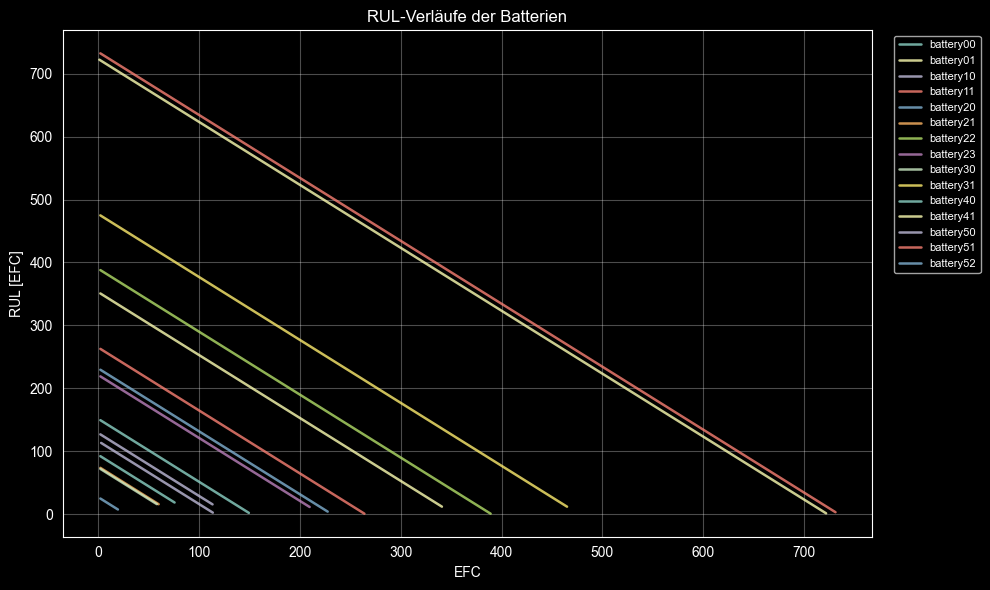

In [108]:
plt.figure(figsize=(10, 6))

for batt, group in df_regular_no_ref.groupby("batt_label"):
    group = group.sort_values("EFC")

    plt.plot(
        group["EFC"],
        group["RUL_EFC"],
        linewidth=1.8,
        alpha=0.8,
        label=batt
    )

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("RUL-Verläufe der Batterien")
plt.grid(True, alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)
plt.tight_layout()
plt.show()

# Lebensdauer pro Batterie

In [38]:
battery_lifetime = (
    df_regular_no_ref
    .groupby("batt_label")["RUL_EFC"]
    .max()
    .sort_values()
)

battery_lifetime

batt_label
battery20     24.909938
battery30     71.997279
battery21     73.673828
battery40     92.212724
battery50    113.266444
battery10    126.871385
battery00    149.417193
battery23    219.026150
battery52    229.572564
battery51    262.719479
battery41    350.790108
battery22    387.893845
battery31    474.839035
battery01    722.253698
battery11    732.305407
Name: RUL_EFC, dtype: float64

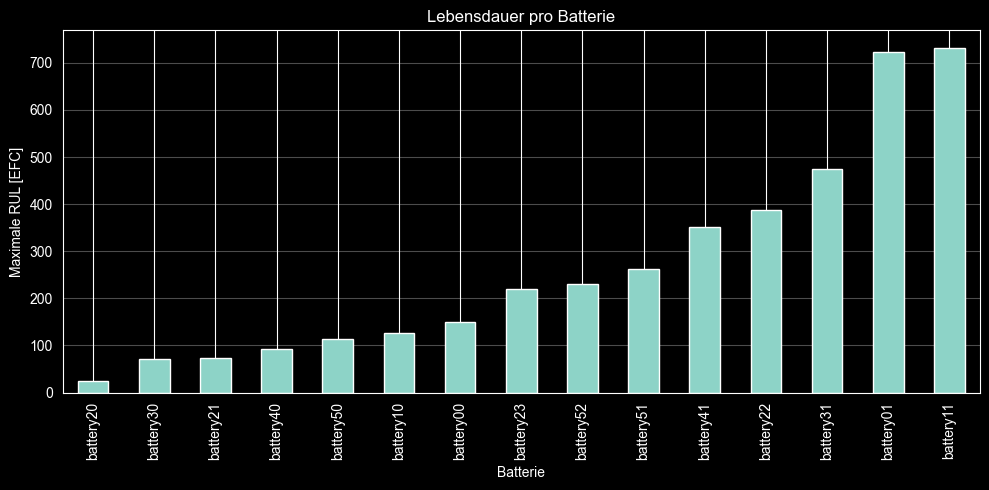

In [39]:
plt.figure(figsize=(10, 5))

battery_lifetime.plot(kind="bar")

plt.ylabel("Maximale RUL [EFC]")
plt.xlabel("Batterie")
plt.title("Lebensdauer pro Batterie")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Lebensdauergruppen

In [40]:
def life_group(max_rul):
    if max_rul < 100:
        return "short"
    elif max_rul < 300:
        return "medium"
    else:
        return "long"

battery_groups_df = battery_lifetime.reset_index()
battery_groups_df.columns = ["batt_label", "max_rul"]
battery_groups_df["life_group"] = battery_groups_df["max_rul"].apply(life_group)

battery_groups_df

,batt_label,max_rul,life_group
0,battery20,24.909938,short
1,battery30,71.997279,short
2,battery21,73.673828,short
3,battery40,92.212724,short
4,battery50,113.266444,medium
5,battery10,126.871385,medium
6,battery00,149.417193,medium
7,battery23,219.026150,medium
8,battery52,229.572564,medium
9,battery51,262.719479,medium


In [41]:
battery_groups = dict(
    zip(
        battery_groups_df["batt_label"],
        battery_groups_df["life_group"]
    )
)

battery_groups_df.groupby("life_group")["batt_label"].apply(list)

life_group
long      [battery41, battery22, battery31, battery01, b...
medium    [battery50, battery10, battery00, battery23, b...
short          [battery20, battery30, battery21, battery40]
Name: batt_label, dtype: object

# Balancierte batteriegetrennte Folds

In [42]:
fold_batteries = {
    0: ["battery20", "battery50", "battery41", "battery11"],
    1: ["battery30", "battery10", "battery22", "battery01"],
    2: ["battery21", "battery00", "battery31", "battery52"],
    3: ["battery40", "battery23", "battery51"]
}

In [43]:
all_test_batts = [b for fold in fold_batteries.values() for b in fold]

print("Anzahl Test-Batterien:", len(all_test_batts))
print("Eindeutige Test-Batterien:", len(set(all_test_batts)))
print("Fehlende Batterien:", set(regular_batteries) - set(all_test_batts))
print("Doppelte Batterien:", [b for b in all_test_batts if all_test_batts.count(b) > 1])

Anzahl Test-Batterien: 15
Eindeutige Test-Batterien: 15
Fehlende Batterien: set()
Doppelte Batterien: []


In [44]:
fold_overview = []

for fold, batts in fold_batteries.items():
    for batt in batts:
        fold_overview.append({
            "fold": fold,
            "batt_label": batt,
            "max_rul": battery_lifetime.loc[batt],
            "life_group": battery_groups[batt]
        })

fold_overview_df = pd.DataFrame(fold_overview)

fold_overview_df.sort_values(["fold", "life_group", "batt_label"])

,fold,batt_label,max_rul,life_group
3,0,battery11,732.305407,long
2,0,battery41,350.790108,long
1,0,battery50,113.266444,medium
0,0,battery20,24.909938,short
7,1,battery01,722.253698,long
6,1,battery22,387.893845,long
5,1,battery10,126.871385,medium
4,1,battery30,71.997279,short
10,2,battery31,474.839035,long
9,2,battery00,149.417193,medium


In [45]:
fold_overview_df.groupby(["fold", "life_group"])["batt_label"].apply(list)

fold  life_group
0     long          [battery41, battery11]
      medium                   [battery50]
      short                    [battery20]
1     long          [battery22, battery01]
      medium                   [battery10]
      short                    [battery30]
2     long                     [battery31]
      medium        [battery00, battery52]
      short                    [battery21]
3     medium        [battery23, battery51]
      short                    [battery40]
Name: batt_label, dtype: object

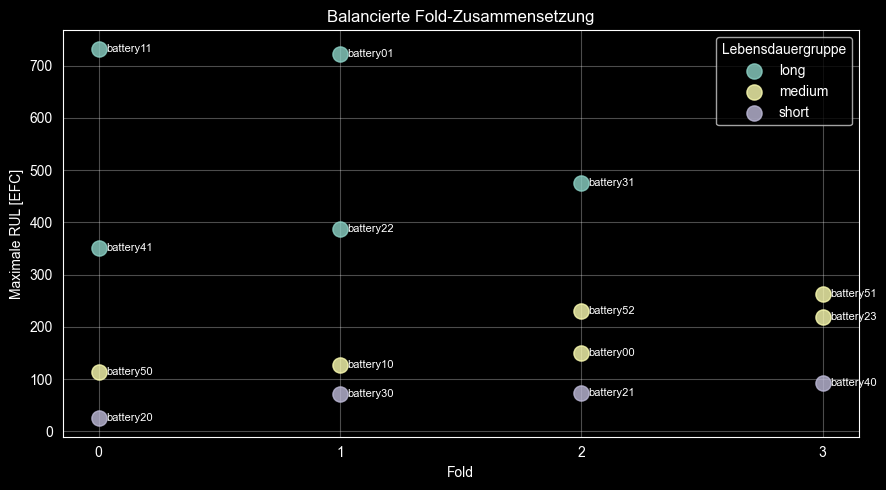

In [111]:
plt.figure(figsize=(9, 5))

for life_group_name, group_df in fold_overview_df.groupby("life_group"):
    plt.scatter(
        group_df["fold"],
        group_df["max_rul"],
        s=120,
        label=life_group_name,
        alpha=0.8
    )

for _, row in fold_overview_df.iterrows():
    plt.text(
        row["fold"] + 0.03,
        row["max_rul"],
        row["batt_label"],
        fontsize=8,
        va="center"
    )

plt.xlabel("Fold")
plt.ylabel("Maximale RUL [EFC]")
plt.title("Balancierte Fold-Zusammensetzung")
plt.xticks(sorted(fold_batteries.keys()))
plt.grid(True, alpha=0.3)
plt.legend(title="Lebensdauergruppe")
plt.tight_layout()
plt.show()

# Evaluierungsfunktion

In [46]:
def evaluate_model(model, model_name, feature_set_name, X, y, df_ml, fold_batteries):
    results = []
    predictions = []

    for fold, test_batts in fold_batteries.items():
        test_mask = df_ml["batt_label"].isin(test_batts)
        train_mask = ~test_mask

        X_train = X.loc[train_mask]
        X_test = X.loc[test_mask]
        y_train = y.loc[train_mask]
        y_test = y.loc[test_mask]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # RUL kann physikalisch nicht negativ sein
        y_pred = np.clip(y_pred, 0, y_train.max())

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "fold": fold,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "test_batteries": test_batts
        })

        fold_pred = df_ml.loc[test_mask].copy()
        fold_pred["fold"] = fold
        fold_pred["RUL_pred"] = y_pred
        fold_pred["model"] = model_name
        fold_pred["feature_set"] = feature_set_name

        predictions.append(fold_pred)

    results_df = pd.DataFrame(results)
    pred_df = pd.concat(predictions, ignore_index=True)

    return results_df, pred_df

# Baseline-Feature-Set

In [47]:
feature_cols_baseline = [
    "EFC",
    "SOH",
    "C_rate_cycle_avg",
    "C_rate_cum_avg",
    "C_rate_cycle_max",
    "C_rate_cum_max",
    "T_cycle_avg",
    "T_cum_avg",
    "T_cycle_max",
    "T_cum_max",
    "R_mOhm",
    "E_cum_Wh"
]

In [48]:
df_ml_baseline = df_regular_no_ref[
    ["batt_label", "RUL_EFC"] + feature_cols_baseline
].copy().dropna()

X_baseline = df_ml_baseline[feature_cols_baseline]
y_baseline = df_ml_baseline["RUL_EFC"]

print(df_ml_baseline.shape)

(4305, 14)


# Neues Degradationsfeature-Set

In [93]:
feature_cols_degradation = [
    "SOH",
    "C_rate_cycle_avg",
    "T_cum_max",
    "T_cum_avg",
    "T_cycle_max",
    "sec_T_over_60",
    "R_mOhm",
    "delta_SOH(-120EFC)",
    "EFC",
    "integral_high_temp_high_discharge"
]

In [94]:
missing_cols = [col for col in feature_cols_degradation if col not in df_regular_no_ref.columns]

if len(missing_cols) == 0:
    print("Alle Degradationsfeatures vorhanden.")
else:
    print("Fehlende Features:", missing_cols)

Alle Degradationsfeatures vorhanden.


In [95]:
df_ml_degradation = df_regular_no_ref[
    ["batt_label", "RUL_EFC"] + feature_cols_degradation
].copy().dropna()

X_degradation = df_ml_degradation[feature_cols_degradation]
y_degradation = df_ml_degradation["RUL_EFC"]

print(df_ml_degradation.shape)

(4305, 12)


# Baseline-Modelle testen

In [96]:
models_baseline = {
    "Ridge Regression baseline": make_pipeline(
        StandardScaler(),
        Ridge(alpha=10)
    ),
    "SVR baseline": make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, epsilon=5, gamma="scale")
    )
}

In [97]:
baseline_results = []
baseline_predictions = []

for model_name, model in models_baseline.items():
    results_df, pred_df = evaluate_model(
        model=model,
        model_name=model_name,
        feature_set_name="baseline features",
        X=X_baseline,
        y=y_baseline,
        df_ml=df_ml_baseline,
        fold_batteries=fold_batteries
    )

    baseline_results.append(results_df)
    baseline_predictions.append(pred_df)

baseline_results_df = pd.concat(baseline_results, ignore_index=True)
baseline_predictions_df = pd.concat(baseline_predictions, ignore_index=True)

baseline_results_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,baseline features,Ridge Regression baseline,0,55.726090,59.888646,0.913634,"[battery20, battery50, battery41, battery11]"
1,baseline features,Ridge Regression baseline,1,36.195097,40.188295,0.959290,"[battery30, battery10, battery22, battery01]"
2,baseline features,Ridge Regression baseline,2,32.267515,36.181889,0.919602,"[battery21, battery00, battery31, battery52]"
3,baseline features,Ridge Regression baseline,3,77.900917,86.030988,-0.537977,"[battery40, battery23, battery51]"
4,baseline features,SVR baseline,0,48.855608,58.515033,0.917551,"[battery20, battery50, battery41, battery11]"
5,baseline features,SVR baseline,1,36.522785,41.548252,0.956488,"[battery30, battery10, battery22, battery01]"
6,baseline features,SVR baseline,2,40.694022,54.238834,0.819331,"[battery21, battery00, battery31, battery52]"
7,baseline features,SVR baseline,3,52.746950,59.454333,0.265474,"[battery40, battery23, battery51]"


# Degradationsmodelle testen

In [98]:
models_degradation = {
    "Linear Regression degradation": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    "Ridge Regression degradation": make_pipeline(
        StandardScaler(),
        Ridge(alpha=10)
    ),
    "SVR degradation": make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, epsilon=5, gamma="scale")
    )
}

In [99]:
degradation_results = []
degradation_predictions = []

for model_name, model in models_degradation.items():
    results_df, pred_df = evaluate_model(
        model=model,
        model_name=model_name,
        feature_set_name="degradation features",
        X=X_degradation,
        y=y_degradation,
        df_ml=df_ml_degradation,
        fold_batteries=fold_batteries
    )

    degradation_results.append(results_df)
    degradation_predictions.append(pred_df)

degradation_results_df = pd.concat(degradation_results, ignore_index=True)
degradation_predictions_df = pd.concat(degradation_predictions, ignore_index=True)

degradation_results_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,degradation features,Linear Regression degradation,0,39.115360,43.928374,0.953533,"[battery20, battery50, battery41, battery11]"
1,degradation features,Linear Regression degradation,1,21.274149,27.240048,0.981297,"[battery30, battery10, battery22, battery01]"
2,degradation features,Linear Regression degradation,2,23.182999,29.343795,0.947119,"[battery21, battery00, battery31, battery52]"
3,degradation features,Linear Regression degradation,3,54.209884,63.422996,0.164140,"[battery40, battery23, battery51]"
4,degradation features,Ridge Regression degradation,0,48.591637,53.317512,0.931547,"[battery20, battery50, battery41, battery11]"
5,degradation features,Ridge Regression degradation,1,27.854435,31.366797,0.975200,"[battery30, battery10, battery22, battery01]"
6,degradation features,Ridge Regression degradation,2,26.697912,30.955757,0.941150,"[battery21, battery00, battery31, battery52]"
7,degradation features,Ridge Regression degradation,3,61.730575,71.313689,-0.056783,"[battery40, battery23, battery51]"
8,degradation features,SVR degradation,0,63.315281,77.785036,0.854305,"[battery20, battery50, battery41, battery11]"
9,degradation features,SVR degradation,1,50.077884,62.731323,0.900808,"[battery30, battery10, battery22, battery01]"


In [100]:
degradation_results = []
degradation_predictions = []

for model_name, model in models_degradation.items():
    results_df, pred_df = evaluate_model(
        model=model,
        model_name=model_name,
        feature_set_name="degradation features",
        X=X_degradation,
        y=y_degradation,
        df_ml=df_ml_degradation,
        fold_batteries=fold_batteries
    )

    degradation_results.append(results_df)
    degradation_predictions.append(pred_df)

degradation_results_df = pd.concat(degradation_results, ignore_index=True)
degradation_predictions_df = pd.concat(degradation_predictions, ignore_index=True)

degradation_results_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,degradation features,Linear Regression degradation,0,39.115360,43.928374,0.953533,"[battery20, battery50, battery41, battery11]"
1,degradation features,Linear Regression degradation,1,21.274149,27.240048,0.981297,"[battery30, battery10, battery22, battery01]"
2,degradation features,Linear Regression degradation,2,23.182999,29.343795,0.947119,"[battery21, battery00, battery31, battery52]"
3,degradation features,Linear Regression degradation,3,54.209884,63.422996,0.164140,"[battery40, battery23, battery51]"
4,degradation features,Ridge Regression degradation,0,48.591637,53.317512,0.931547,"[battery20, battery50, battery41, battery11]"
5,degradation features,Ridge Regression degradation,1,27.854435,31.366797,0.975200,"[battery30, battery10, battery22, battery01]"
6,degradation features,Ridge Regression degradation,2,26.697912,30.955757,0.941150,"[battery21, battery00, battery31, battery52]"
7,degradation features,Ridge Regression degradation,3,61.730575,71.313689,-0.056783,"[battery40, battery23, battery51]"
8,degradation features,SVR degradation,0,63.315281,77.785036,0.854305,"[battery20, battery50, battery41, battery11]"
9,degradation features,SVR degradation,1,50.077884,62.731323,0.900808,"[battery30, battery10, battery22, battery01]"


# Modellvergleich

In [101]:
all_results_df = pd.concat(
    [
        baseline_results_df,
        degradation_results_df
    ],
    ignore_index=True
)

comparison = (
    all_results_df
    .groupby(["model", "feature_set"])[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
    .sort_values("MAE")
)

comparison

,model,feature_set,MAE,RMSE,R2
0,Linear Regression degradation,degradation features,34.445598,40.983803,0.761522
2,Ridge Regression degradation,degradation features,41.218640,46.738439,0.697779
3,SVR baseline,baseline features,44.704841,53.439113,0.739711
4,SVR degradation,degradation features,48.001655,61.683177,0.713879
1,Ridge Regression baseline,baseline features,50.522405,55.572454,0.563637


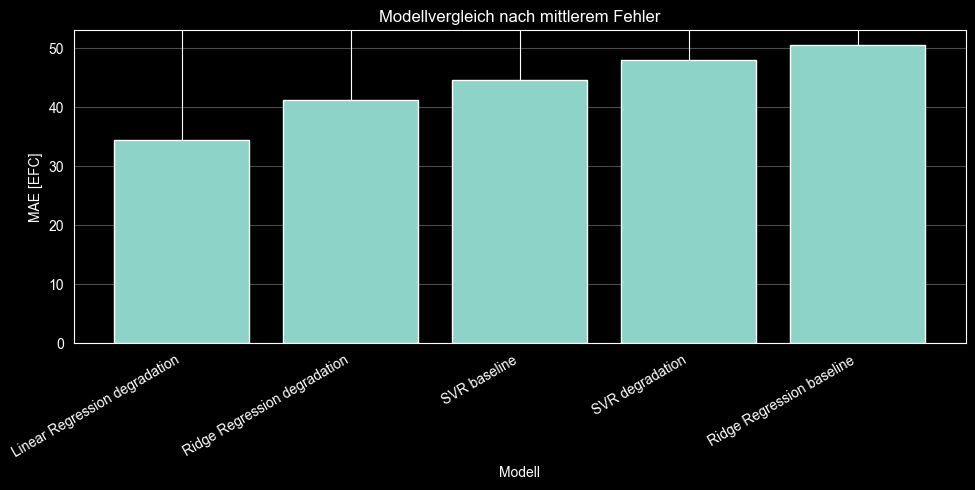

In [102]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["model"],
    comparison["MAE"]
)

plt.ylabel("MAE [EFC]")
plt.xlabel("Modell")
plt.title("Modellvergleich nach mittlerem Fehler")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Bestes Modell auswählen

In [103]:
best_row = comparison.iloc[0]

best_model_name = best_row["model"]
best_feature_set = best_row["feature_set"]

print("Bestes Modell:", best_model_name)
print("Feature-Set:", best_feature_set)
print(f"MAE:  {best_row['MAE']:.2f} EFC")
print(f"RMSE: {best_row['RMSE']:.2f} EFC")
print(f"R²:   {best_row['R2']:.3f}")

Bestes Modell: Linear Regression degradation
Feature-Set: degradation features
MAE:  34.45 EFC
RMSE: 40.98 EFC
R²:   0.762


In [104]:
if best_feature_set == "baseline features":
    best_pred_df = baseline_predictions_df[
        baseline_predictions_df["model"] == best_model_name
    ].copy()
else:
    best_pred_df = degradation_predictions_df[
        degradation_predictions_df["model"] == best_model_name
    ].copy()

best_pred_df.head()

,batt_label,RUL_EFC,SOH,C_rate_cycle_avg,T_cum_max,T_cum_avg,T_cycle_max,sec_T_over_60,R_mOhm,delta_SOH(-120EFC),EFC,integral_high_temp_high_discharge,fold,RUL_pred,model,feature_set
0,battery11,732.305407,99.922193,3.639477,48.543,27.026058,48.543,0.0,52.731744,0.077807,2.002539,4354.836328,0,722.253698,Linear Regression degradation,degradation features
1,battery11,731.301371,99.844163,3.637401,49.716,28.349446,49.716,0.0,51.191299,0.155837,3.006575,10129.061524,0,716.964481,Linear Regression degradation,degradation features
2,battery11,730.297469,99.766143,3.637508,49.716,28.983240,49.251,0.0,52.794280,0.233857,4.010477,15586.900161,0,715.402050,Linear Regression degradation,degradation features
3,battery11,729.305629,99.689061,3.789407,49.843,28.897255,49.843,0.0,51.187456,0.310939,5.002317,21196.105066,0,681.481861,Linear Regression degradation,degradation features
4,battery11,728.310184,99.611699,3.789267,49.920,29.273144,49.920,0.0,51.962794,0.388301,5.997762,27153.832564,0,678.417013,Linear Regression degradation,degradation features


# Fehler pro Batterie

In [105]:
battery_errors = (
    best_pred_df
    .assign(abs_error=lambda x: abs(x["RUL_EFC"] - x["RUL_pred"]))
    .groupby("batt_label")["abs_error"]
    .mean()
    .sort_values()
)

battery_errors

batt_label
battery00    15.612017
battery20    15.837624
battery01    17.698755
battery31    18.384341
battery22    20.037044
battery40    28.410365
battery21    31.785203
battery51    35.998276
battery52    36.465311
battery11    37.807226
battery10    39.765967
battery50    40.283646
battery30    42.354307
battery41    42.761178
battery23    86.418125
Name: abs_error, dtype: float64

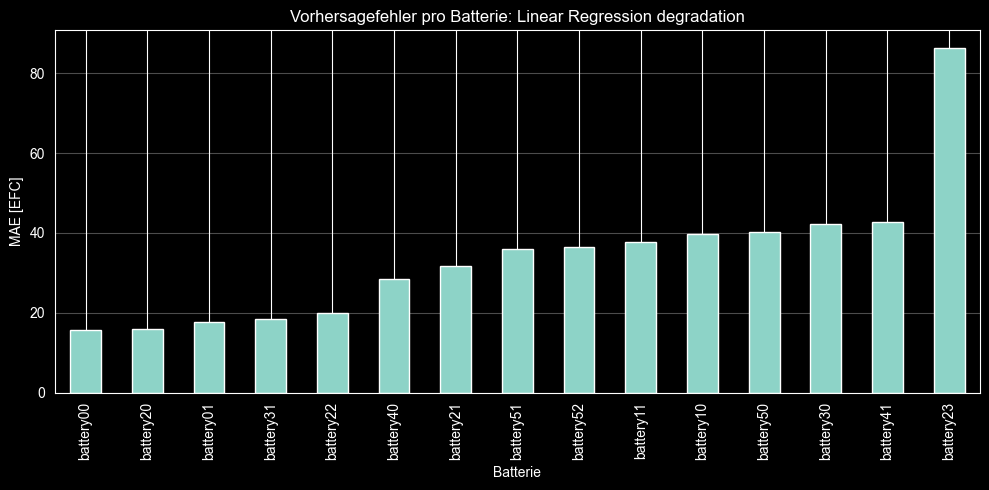

In [106]:
plt.figure(figsize=(10, 5))

battery_errors.plot(kind="bar")

plt.ylabel("MAE [EFC]")
plt.xlabel("Batterie")
plt.title(f"Vorhersagefehler pro Batterie: {best_model_name}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Beste und schlechteste Batterie plotten

In [112]:
best_batt = battery_errors.index[0]
worst_batt = battery_errors.index[-1]

print("Beste Batterie:", best_batt, "| MAE:", round(battery_errors.loc[best_batt], 2), "EFC")
print("Schlechteste Batterie:", worst_batt, "| MAE:", round(battery_errors.loc[worst_batt], 2), "EFC")

Beste Batterie: battery00 | MAE: 15.61 EFC
Schlechteste Batterie: battery23 | MAE: 86.42 EFC


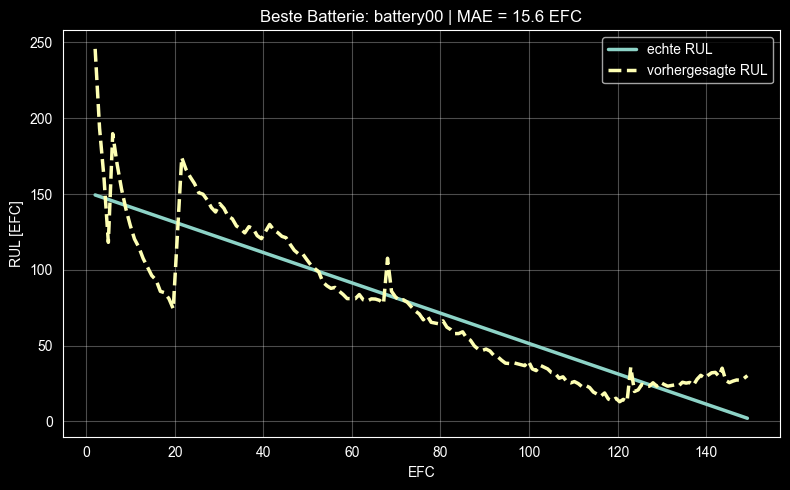

In [113]:
# Beste Batterie
batt = best_batt

group = best_pred_df[best_pred_df["batt_label"] == batt].copy()
group = group.sort_values("EFC")

plt.figure(figsize=(8, 5))

plt.plot(
    group["EFC"],
    group["RUL_EFC"],
    linewidth=2.5,
    label="echte RUL"
)

plt.plot(
    group["EFC"],
    group["RUL_pred"],
    linestyle="--",
    linewidth=2.5,
    label="vorhergesagte RUL"
)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"Beste Batterie: {batt} | MAE = {battery_errors.loc[batt]:.1f} EFC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

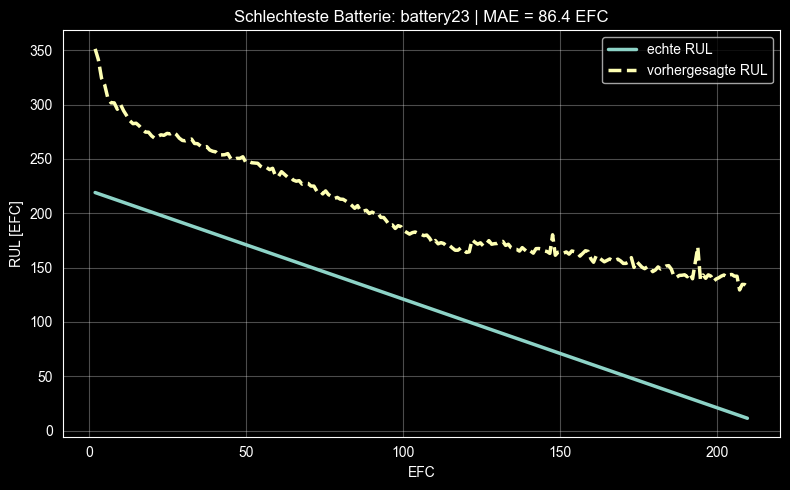

In [114]:
# Schlechteste Batterie
batt = worst_batt

group = best_pred_df[best_pred_df["batt_label"] == batt].copy()
group = group.sort_values("EFC")

plt.figure(figsize=(8, 5))

plt.plot(
    group["EFC"],
    group["RUL_EFC"],
    linewidth=2.5,
    label="echte RUL"
)

plt.plot(
    group["EFC"],
    group["RUL_pred"],
    linestyle="--",
    linewidth=2.5,
    label="vorhergesagte RUL"
)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"Schlechteste Batterie: {batt} | MAE = {battery_errors.loc[batt]:.1f} EFC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Residual-Plot

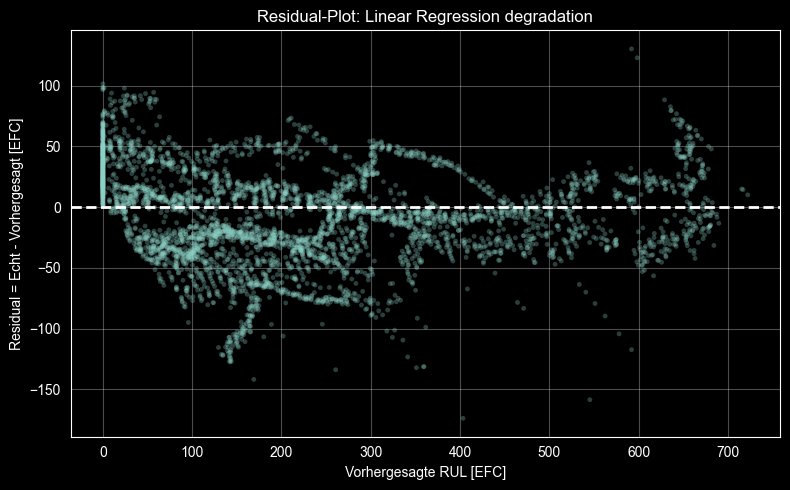

In [115]:
best_pred_df["Residual"] = best_pred_df["RUL_EFC"] - best_pred_df["RUL_pred"]

plt.figure(figsize=(8, 5))

plt.scatter(
    best_pred_df["RUL_pred"],
    best_pred_df["Residual"],
    alpha=0.3,
    s=12,
    edgecolors="none"
)

plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("Vorhergesagte RUL [EFC]")
plt.ylabel("Residual = Echt - Vorhergesagt [EFC]")
plt.title(f"Residual-Plot: {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# True vs. Predicted

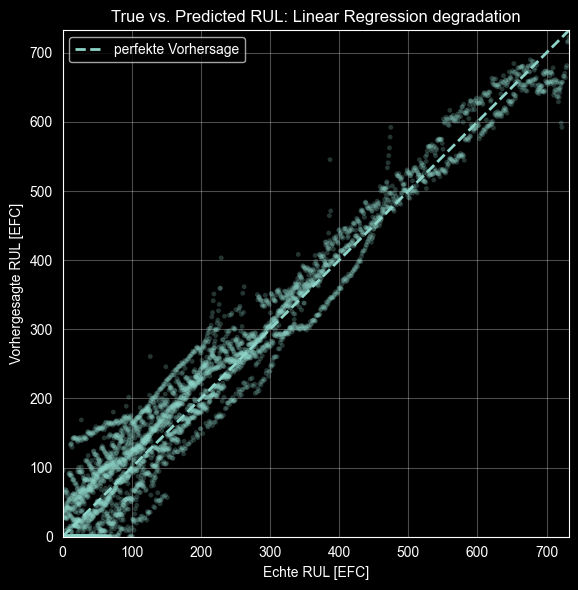

In [116]:
plt.figure(figsize=(7, 6))

plt.scatter(
    best_pred_df["RUL_EFC"],
    best_pred_df["RUL_pred"],
    alpha=0.25,
    s=12,
    edgecolors="none"
)

min_val = 0
max_val = max(best_pred_df["RUL_EFC"].max(), best_pred_df["RUL_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="perfekte Vorhersage"
)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Echte RUL [EFC]")
plt.ylabel("Vorhergesagte RUL [EFC]")
plt.title(f"True vs. Predicted RUL: {best_model_name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Fazit

Finales Modell: Linear Regression mit Degradationsfeatures

Das beste Ergebnis wurde mit Linear Regression und dem Degradationsfeature-Set erreicht. Das finale Feature-Set enthält neben aktuellen Zustandsgrößen wie SOH und R_mOhm auch Nutzungs- und Belastungsmerkmale wie EFC, Temperaturfeatures und ein Degradationsmerkmal. Besonders wichtig ist `delta_SOH(-120EFC)`, da es die Veränderung des SOH über die vergangenen 120 EFC beschreibt und damit die aktuelle Alterungsgeschwindigkeit abbildet.

Durch das zusätzliche Feature `T_cycle_max` konnte der mittlere Fehler leicht weiter reduziert werden. Das finale Modell erreicht einen MAE von 34.45 EFC, einen RMSE von 40.98 EFC und ein R² von 0.762.